In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:

df = pd.read_csv("merged_output.csv")


In [35]:
for col in df.columns:
    if "datetime" in col:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [36]:
df.shape

(876100, 32)

In [44]:
df.isnull().sum()

errors_datetime                              0
errors_machineID                             0
errors_errorID                               0
failures_datetime                            0
failures_machineID                           0
failures_failure                             0
failures_features_datetime                   0
failures_features_machineID                  0
failures_features_failure                    0
failures_features_failure_comp1              0
failures_features_failure_comp2              0
failures_features_failure_comp3              0
failures_features_failure_comp4              0
failures_features_days_since_last_failure    0
failures_features_cumulative_failures        0
failures_features_hour                       0
failures_features_dayofweek                  0
failures_features_month                      0
failures_features_quarter                    0
failures_features_is_weekend                 0
machines_machineID                           0
machines_mode

In [45]:
df.describe()

,errors_datetime,errors_machineID,failures_datetime,failures_machineID,failures_features_datetime,failures_features_machineID,failures_features_days_since_last_failure,failures_features_cumulative_failures,failures_features_hour,failures_features_dayofweek,...,machines_machineID,machines_age,maint_datetime,maint_machineID,telemetry_datetime,telemetry_machineID,telemetry_volt,telemetry_rotate,telemetry_pressure,telemetry_vibration
count,876100,876100.000000,876100,876100.000000,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000,...,876100.000000,876100.000000,876100,876100.000000,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-01 03:38:23.609633,50.989064,2015-06-24 12:12:09.459193,51.903794,2015-06-24 12:12:09.459193,51.903794,37.519899,5.147245,5.929042,2.951364,...,50.500000,11.330000,2015-05-30 14:37:10.923411,50.239838,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,2015-01-02 03:00:00,1.000000,2015-01-02 03:00:00,1.000000,-1.000000,1.000000,3.000000,0.000000,...,1.000000,0.000000,2014-06-01 06:00:00,1.000000,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-03-31 04:00:00,25.000000,2015-03-23 06:00:00,24.000000,2015-03-23 06:00:00,24.000000,15.000000,2.000000,6.000000,1.000000,...,25.750000,6.750000,2015-03-03 06:00:00,25.000000,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-01 06:00:00,51.000000,2015-06-24 06:00:00,51.000000,2015-06-24 06:00:00,51.000000,30.000000,5.000000,6.000000,3.000000,...,50.500000,12.000000,2015-06-13 06:00:00,50.000000,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-01 15:00:00,76.000000,2015-09-23 06:00:00,79.000000,2015-09-23 06:00:00,79.000000,60.000000,7.000000,6.000000,5.000000,...,75.250000,16.000000,2015-09-18 06:00:00,75.000000,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 05:00:00,100.000000,2015-12-31 06:00:00,100.000000,2015-12-31 06:00:00,100.000000,270.000000,19.000000,6.000000,6.000000,...,100.000000,20.000000,2016-01-01 06:00:00,100.000000,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.948054,NaN,29.498372,NaN,29.498372,39.018864,3.363979,0.455893,1.962598,...,28.866087,5.827619,NaN,28.904112,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [43]:

df["failures_features_days_since_last_failure"] = df["failures_features_days_since_last_failure"].fillna(-1)

In [47]:
df.columns


Index(['errors_datetime', 'errors_machineID', 'errors_errorID',
       'failures_datetime', 'failures_machineID', 'failures_failure',
       'failures_features_datetime', 'failures_features_machineID',
       'failures_features_failure', 'failures_features_failure_comp1',
       'failures_features_failure_comp2', 'failures_features_failure_comp3',
       'failures_features_failure_comp4',
       'failures_features_days_since_last_failure',
       'failures_features_cumulative_failures', 'failures_features_hour',
       'failures_features_dayofweek', 'failures_features_month',
       'failures_features_quarter', 'failures_features_is_weekend',
       'machines_machineID', 'machines_model', 'machines_age',
       'maint_datetime', 'maint_machineID', 'maint_comp', 'telemetry_datetime',
       'telemetry_machineID', 'telemetry_volt', 'telemetry_rotate',
       'telemetry_pressure', 'telemetry_vibration'],
      dtype='str')

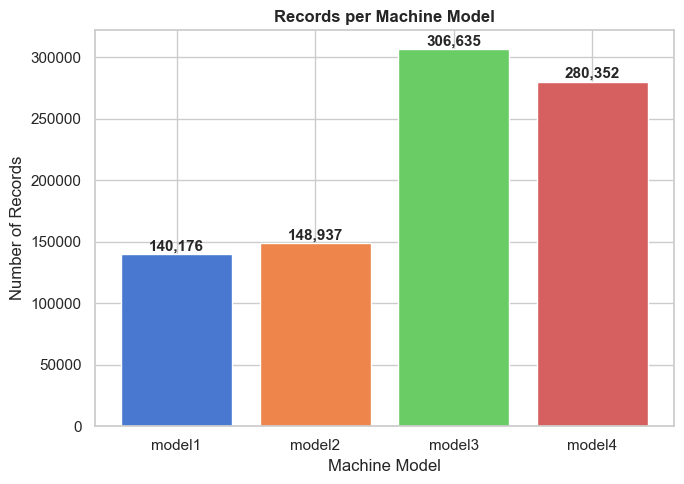

In [48]:
model_counts = df["machines_model"].value_counts().sort_index()
colors = sns.color_palette("muted", len(model_counts))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(model_counts.index, model_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, model_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3000,
            f"{val:,}", ha="center", fontsize=11, fontweight="bold")

ax.set_title("Records per Machine Model")
ax.set_xlabel("Machine Model")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.savefig("plot02_model_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

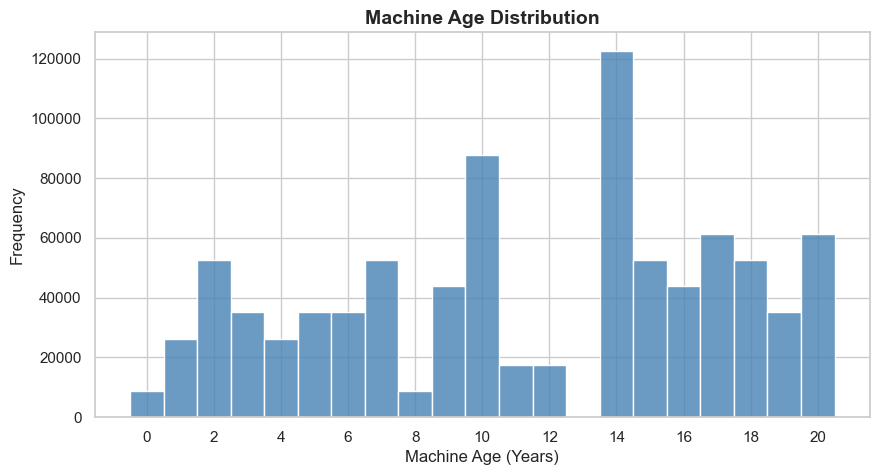

In [49]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='machines_age', discrete=True, color='steelblue', alpha=0.8)
plt.title('Machine Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Machine Age (Years)')
plt.ylabel('Frequency')
plt.xticks(range(0, int(df['machines_age'].max()) + 1, 2)) 
plt.show()

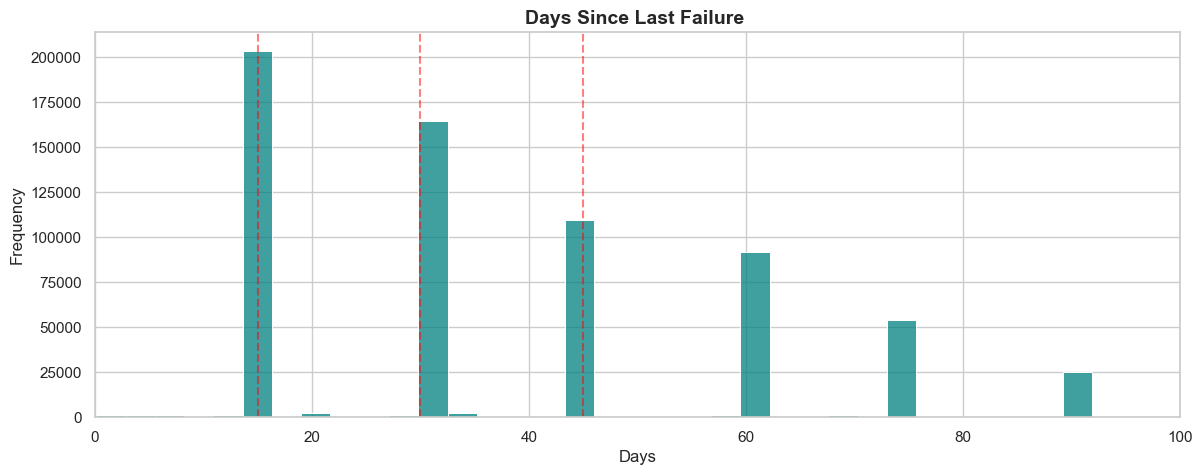

In [51]:
plt.figure(figsize=(14, 5))
real_failures = df[df['failures_features_days_since_last_failure'] > 0]
sns.histplot(data=real_failures, x='failures_features_days_since_last_failure', bins=100, color='teal')
plt.title('Days Since Last Failure ', fontsize=14, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.xlim(0, 100) 
plt.axvline(15, color='red', linestyle='--', alpha=0.5)
plt.axvline(30, color='red', linestyle='--', alpha=0.5)
plt.axvline(45, color='red', linestyle='--', alpha=0.5)
plt.show()

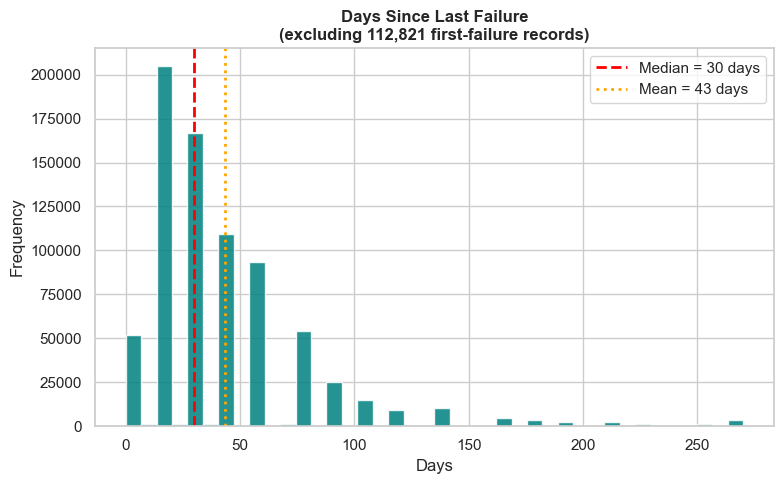

In [52]:
days_col = df["failures_features_days_since_last_failure"].dropna()
days_valid = days_col[days_col >= 0] 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(days_valid, bins=40, color="teal", edgecolor="white", alpha=0.85)
ax.axvline(days_valid.median(), color="red", linestyle="--", linewidth=2,
           label=f"Median = {days_valid.median():.0f} days")
ax.axvline(days_valid.mean(), color="orange", linestyle=":", linewidth=2,
           label=f"Mean = {days_valid.mean():.0f} days")

ax.set_title(f"Days Since Last Failure\n(excluding {(days_col == -1).sum():,} first-failure records)")
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("plot05_days_since_failure.png", dpi=150, bbox_inches="tight")
plt.show()

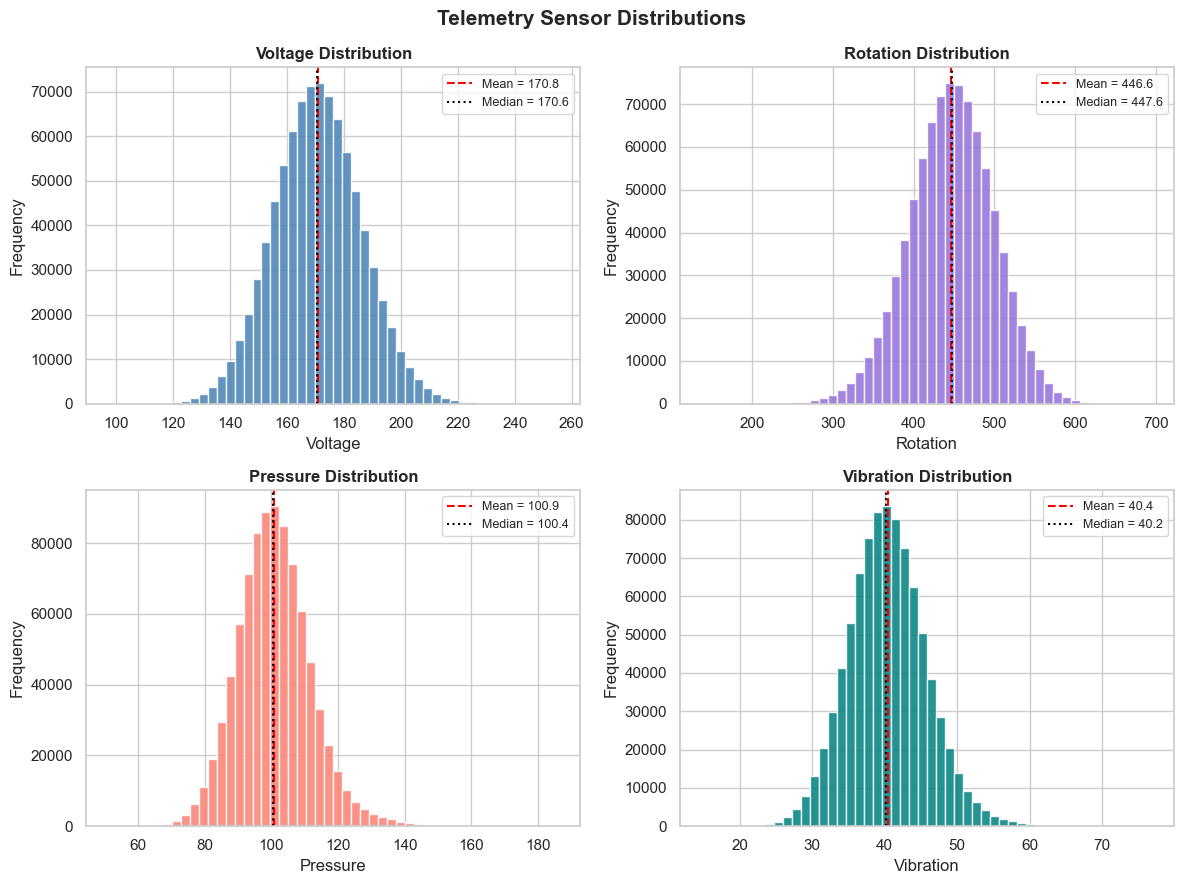

In [53]:
tele_cols   = ["telemetry_volt", "telemetry_rotate",
               "telemetry_pressure", "telemetry_vibration"]
tele_labels = ["Voltage", "Rotation", "Pressure", "Vibration"]
tele_colors = ["steelblue", "mediumpurple", "salmon", "teal"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(tele_cols, tele_labels, tele_colors)):
    ax = axes[i]
    vals = df[col].dropna()
    ax.hist(vals, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="red", linestyle="--", linewidth=1.5,
               label=f"Mean = {vals.mean():.1f}")
    ax.axvline(vals.median(), color="black", linestyle=":", linewidth=1.5,
               label=f"Median = {vals.median():.1f}")
    ax.set_title(f"{label} Distribution")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Telemetry Sensor Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot07_telemetry_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


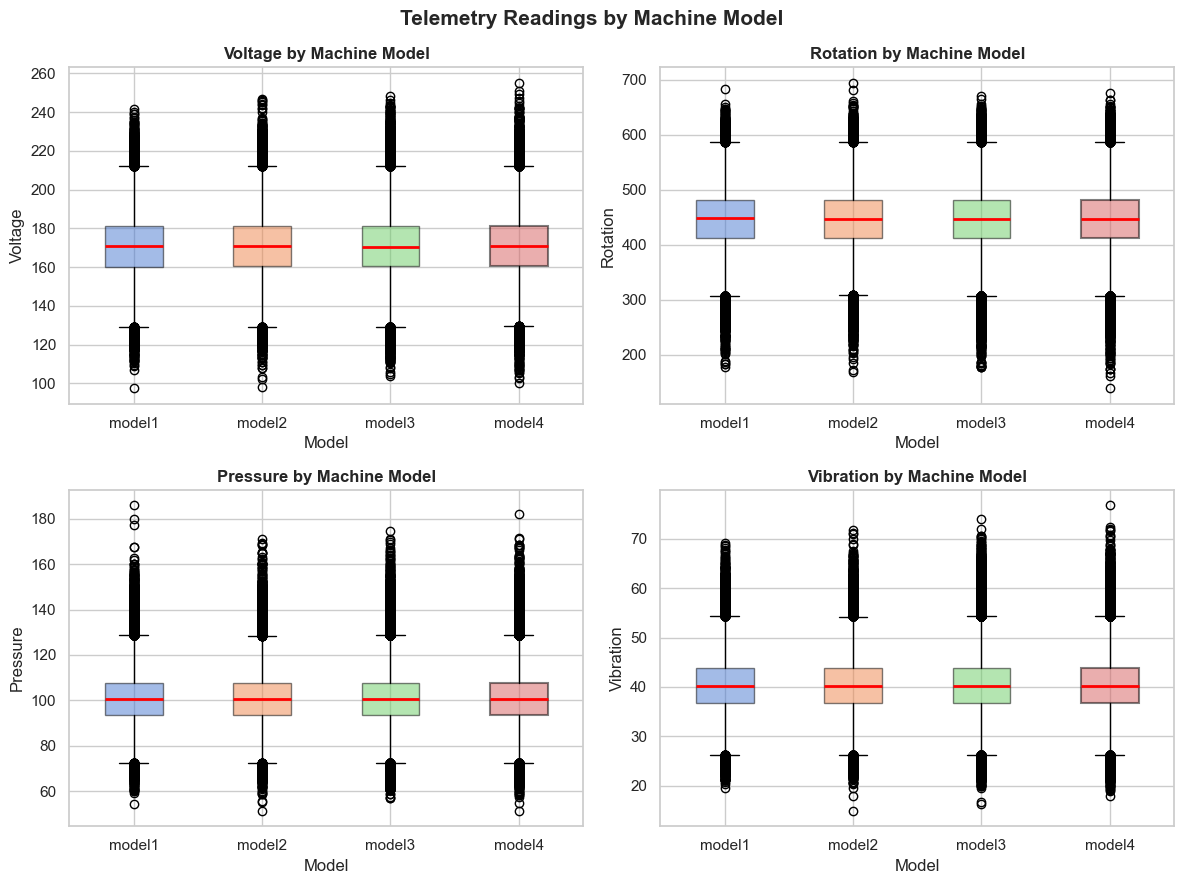

In [54]:
tele_cols   = ["telemetry_volt", "telemetry_rotate",
               "telemetry_pressure", "telemetry_vibration"]
tele_labels = ["Voltage", "Rotation", "Pressure", "Vibration"]
models = sorted(df["machines_model"].unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(tele_cols, tele_labels)):
    ax = axes[i]
    data = [df.loc[df["machines_model"] == m, col].dropna().values for m in models]
    bp = ax.boxplot(data, labels=models, patch_artist=True,
                    medianprops=dict(color="red", linewidth=2))
    colors = sns.color_palette("muted", len(models))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_title(f"{label} by Machine Model")
    ax.set_xlabel("Model")
    ax.set_ylabel(label)
    patch.set_linewidth(1.5)

plt.suptitle("Telemetry Readings by Machine Model", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

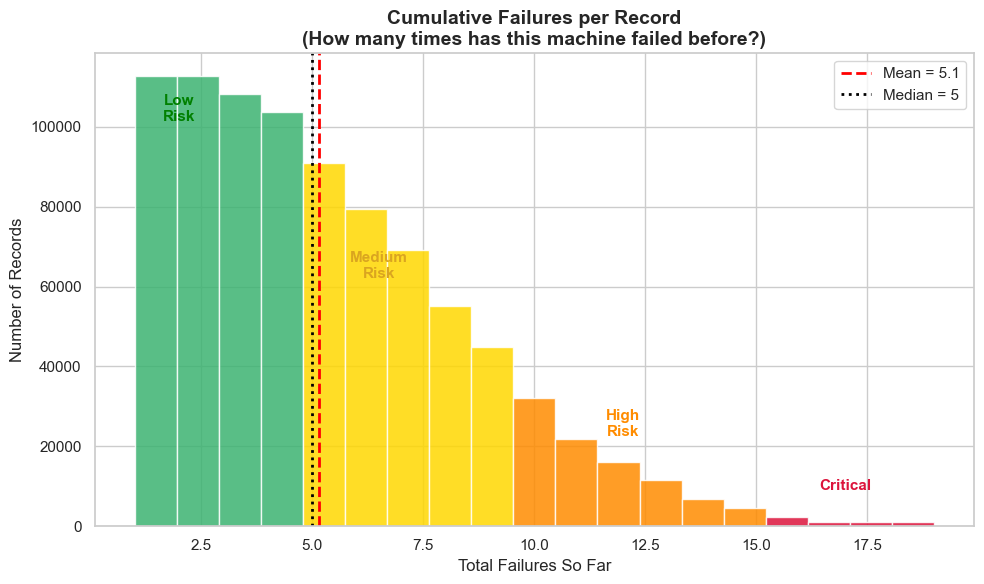

In [55]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.titlesize":   14,
    "axes.titleweight": "bold",
})

df = pd.read_csv("merged_output.csv")
cum_fail = df["failures_features_cumulative_failures"].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

# Color bars by risk zone
counts, bin_edges, patches = ax.hist(
    cum_fail, bins=19, edgecolor="white", alpha=0.85
)

for patch, left_edge in zip(patches, bin_edges):
    if left_edge < 4:
        patch.set_facecolor("mediumseagreen")    # Low risk
    elif left_edge < 9:
        patch.set_facecolor("gold")              # Medium risk
    elif left_edge < 15:
        patch.set_facecolor("darkorange")        
    else:
        patch.set_facecolor("crimson")           

# Add mean and median lines
ax.axvline(cum_fail.mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {cum_fail.mean():.1f}")
ax.axvline(cum_fail.median(), color="black", linestyle=":", linewidth=2,
           label=f"Median = {cum_fail.median():.0f}")

ax.text(2, max(counts)*0.9, "Low\nRisk", fontsize=11,
        ha="center", color="green", fontweight="bold")
ax.text(6.5, max(counts)*0.55, "Medium\nRisk", fontsize=11,
        ha="center", color="goldenrod", fontweight="bold")
ax.text(12, max(counts)*0.2, "High\nRisk", fontsize=11,
        ha="center", color="darkorange", fontweight="bold")
ax.text(17, max(counts)*0.08, "Critical", fontsize=11,
        ha="center", color="crimson", fontweight="bold")

ax.set_title("Cumulative Failures per Record\n(How many times has this machine failed before?)")
ax.set_xlabel("Total Failures So Far")
ax.set_ylabel("Number of Records")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("plot04_cumulative_failures_improved.png", dpi=150, bbox_inches="tight")
plt.show()

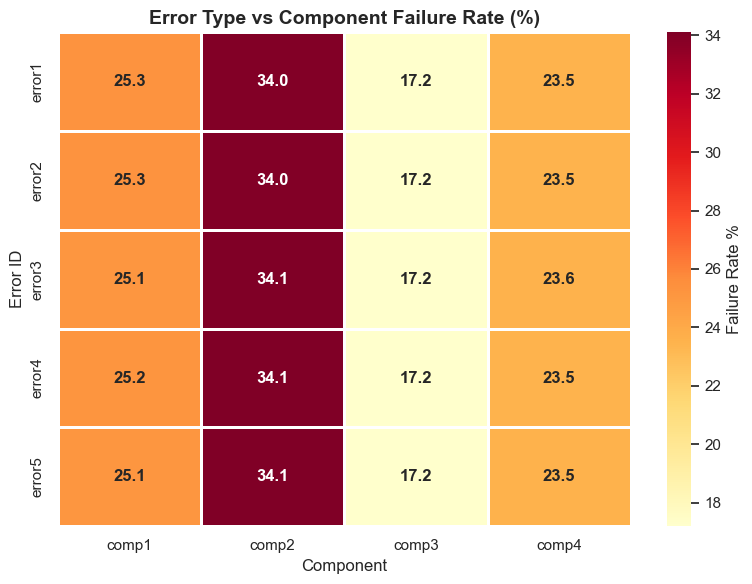

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# تعريف الـ components
comp_names = ["comp1", "comp2", "comp3", "comp4"]

heat_data = {}

for c in comp_names:
    col = f"failures_features_failure_{c}"
    heat_data[c] = df.groupby("errors_errorID")[col].mean() * 100

heat_df = pd.DataFrame(heat_data)

# لو فيه NaN
heat_df = heat_df.fillna(0)

# الرسم
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heat_df,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Failure Rate %"},
    annot_kws={"size": 12, "fontweight": "bold"}
)

ax.set_title("Error Type vs Component Failure Rate (%)")
ax.set_xlabel("Component")
ax.set_ylabel("Error ID")

plt.tight_layout()
plt.savefig("plot16_error_vs_failure_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

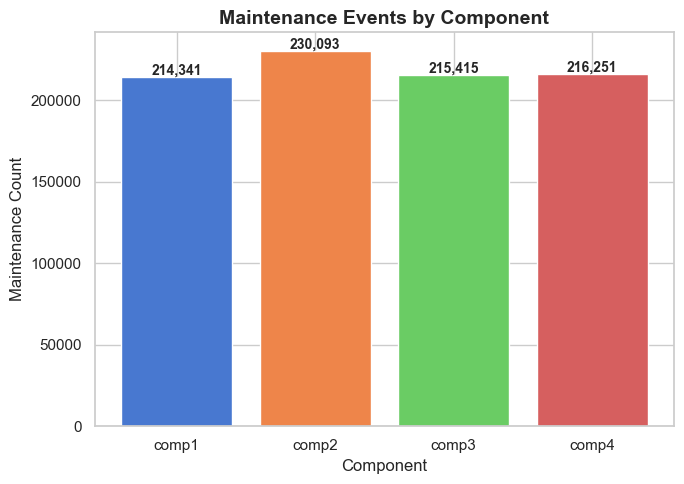

In [57]:
maint_counts = df["maint_comp"].value_counts().sort_index()
colors = sns.color_palette("muted", len(maint_counts))

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(maint_counts.index, maint_counts.values, color=colors, edgecolor="white")

for bar, val in zip(bars, maint_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1500,
            f"{val:,}", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Maintenance Events by Component")
ax.set_xlabel("Component")
ax.set_ylabel("Maintenance Count")

plt.tight_layout()
plt.savefig("plot15_maintenance_by_comp.png", dpi=150, bbox_inches="tight")
plt.show()

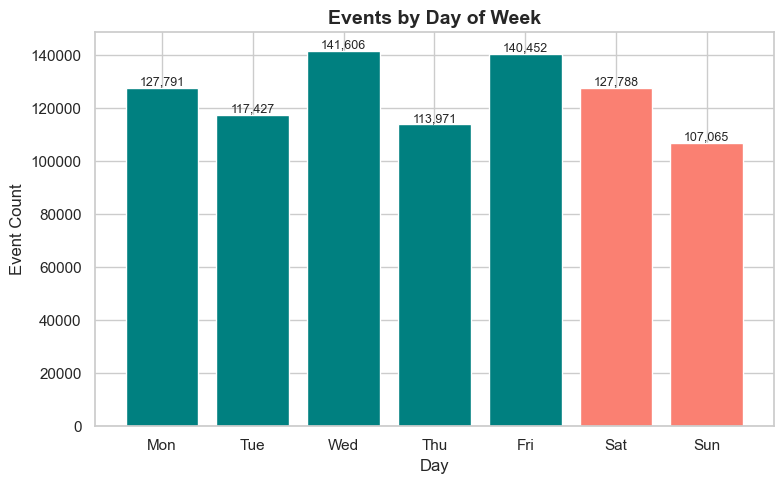

In [58]:
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_counts = df["failures_features_dayofweek"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
values = [dow_counts.get(i, 0) for i in range(7)]
colors = ["teal" if i < 5 else "salmon" for i in range(7)]
bars = ax.bar(dow_labels, values, color=colors, edgecolor="white")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1000,
            f"{val:,}", ha="center", fontsize=9)

ax.set_title("Events by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Event Count")

plt.tight_layout()
plt.show()

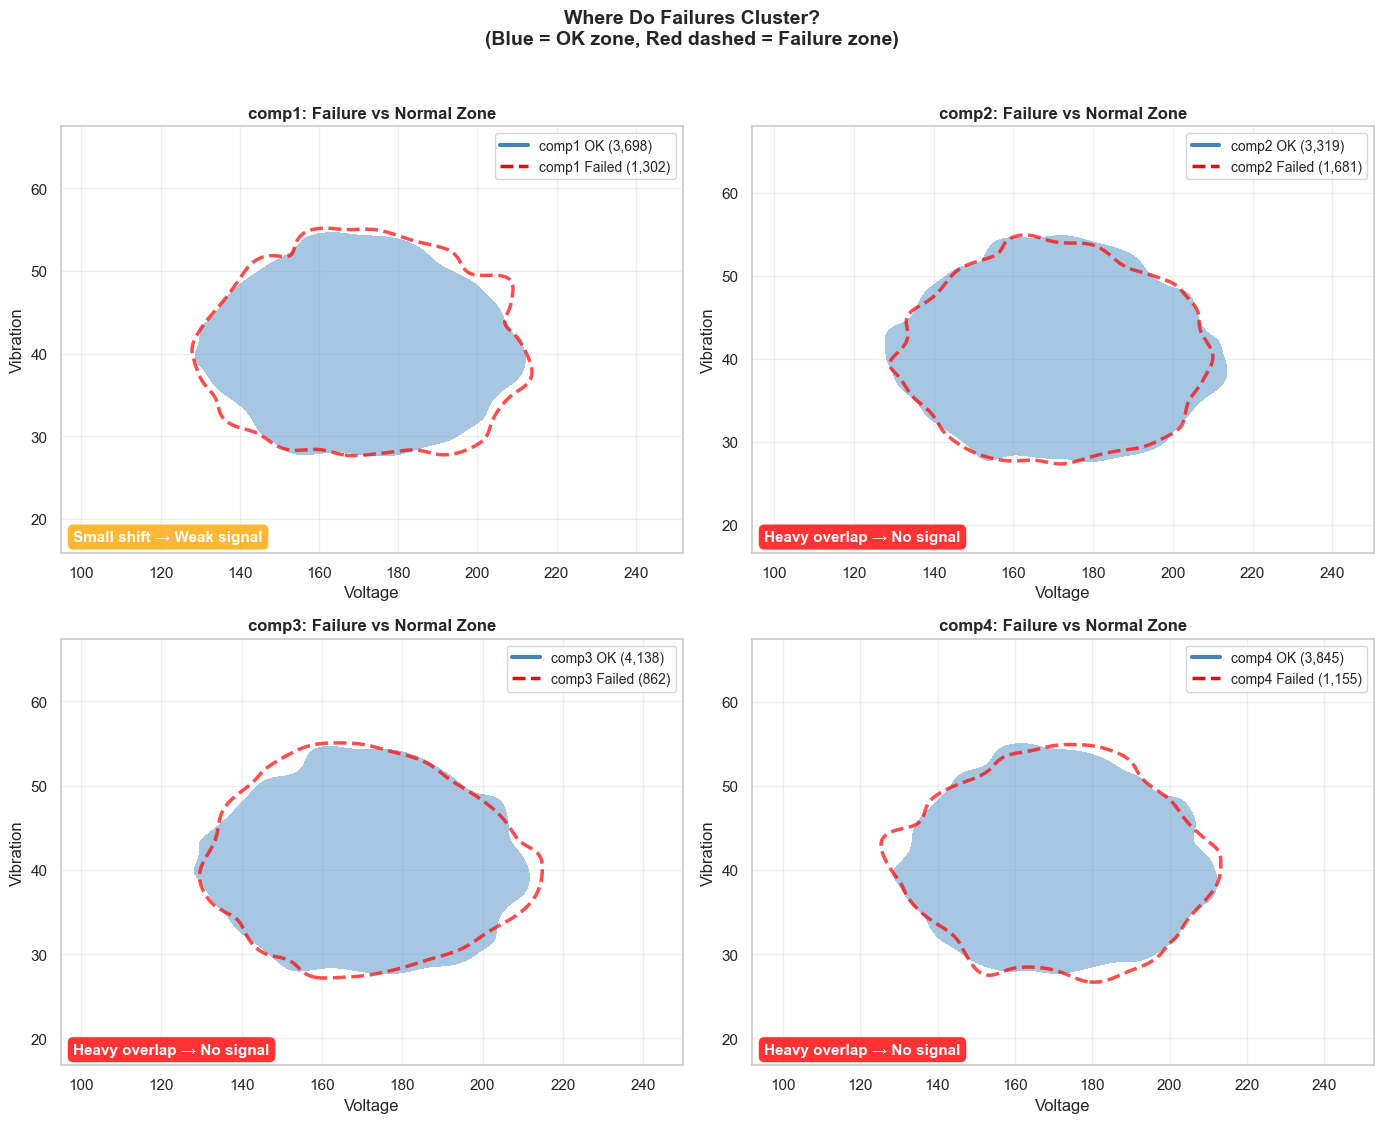

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
})

df = pd.read_csv("merged_output.csv")
sample = df.sample(n=5000, random_state=42)

comp_names = ["comp1", "comp2", "comp3", "comp4"]
verdicts = [
    "Small shift → Weak signal",
    "Heavy overlap → No signal",
    "Heavy overlap → No signal",
    "Heavy overlap → No signal"
]
verdict_colors = ["orange", "red", "red", "red"]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (comp, verdict, vc) in enumerate(zip(comp_names, verdicts, verdict_colors)):
    ax = axes[i]
    target = f"failures_features_failure_{comp}"
    fail_mask = sample[target] == True
    ok_mask   = sample[target] == False

    if ok_mask.sum() > 10:
        sns.kdeplot(
            x=sample.loc[ok_mask, "telemetry_volt"],
            y=sample.loc[ok_mask, "telemetry_vibration"],
            ax=ax, color="steelblue",
            levels=2,              
            linewidths=2.5,
            alpha=0.5,
            fill=True
        )

    # Red DASHED = Failure zone (just 1 boundary)
    if fail_mask.sum() > 10:
        sns.kdeplot(
            x=sample.loc[fail_mask, "telemetry_volt"],
            y=sample.loc[fail_mask, "telemetry_vibration"],
            ax=ax, color="red",
            levels=2,              # ← Only 2 rings
            linewidths=2.5,
            linestyles="--",
            alpha=0.7
        )

    # Manual legend
    blue_line = mlines.Line2D([], [], color="steelblue", linewidth=3,
                               label=f"{comp} OK ({ok_mask.sum():,})")
    red_line  = mlines.Line2D([], [], color="red", linewidth=2.5,
                               linestyle="--",
                               label=f"{comp} Failed ({fail_mask.sum():,})")
    ax.legend(handles=[blue_line, red_line], fontsize=10, loc="upper right")

    ax.set_title(f"{comp}: Failure vs Normal Zone")
    ax.set_xlabel("Voltage")
    ax.set_ylabel("Vibration")

    # Verdict box
    ax.text(0.02, 0.02, verdict, transform=ax.transAxes,
            fontsize=11, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor=vc, alpha=0.8),
            verticalalignment="bottom")

    ax.grid(alpha=0.3)

plt.suptitle(
    "Where Do Failures Cluster?\n"
    "(Blue = OK zone, Red dashed = Failure zone)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("plot18_simple_density.png", dpi=150, bbox_inches="tight")
plt.show()

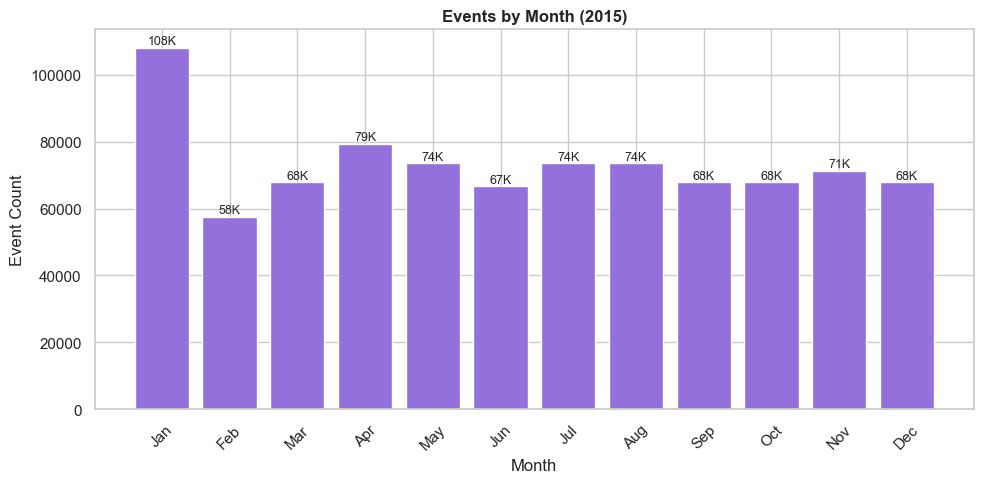

In [60]:
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
month_counts = df["failures_features_month"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
values = [month_counts.get(i, 0) for i in range(1, 13)]
bars = ax.bar(month_labels, values, color="mediumpurple", edgecolor="white")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1000,
            f"{val/1000:.0f}K", ha="center", fontsize=9)

ax.set_title("Events by Month (2015)")
ax.set_xlabel("Month")
ax.set_ylabel("Event Count")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("plot12_events_by_month.png", dpi=150, bbox_inches="tight")
plt.show()

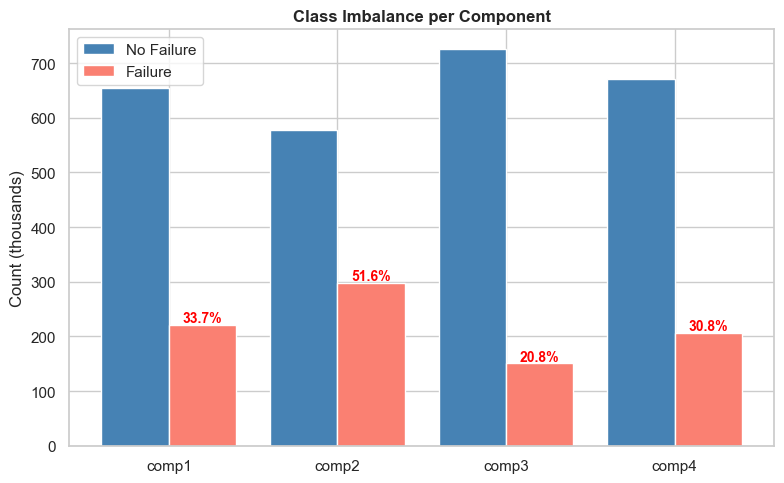

In [61]:
comp_names = ["comp1", "comp2", "comp3", "comp4"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(4)
width = 0.4

fail_true  = np.array([df[f"failures_features_failure_{c}"].sum() for c in comp_names])
fail_false = len(df) - fail_true

bars1 = ax.bar(x - width/2, fail_false/1000, width,
               label="No Failure", color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, fail_true/1000, width,
               label="Failure", color="salmon", edgecolor="white")

for xi, (ft, ff) in enumerate(zip(fail_true, fail_false)):
    ratio = ft / ff * 100
    ax.text(xi + width/2, ft/1000 + 5,
            f"{ratio:.1f}%", ha="center", fontsize=10,
            fontweight="bold", color="red")

ax.set_xticks(x)
ax.set_xticklabels(comp_names)
ax.set_title("Class Imbalance per Component")
ax.set_ylabel("Count (thousands)")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


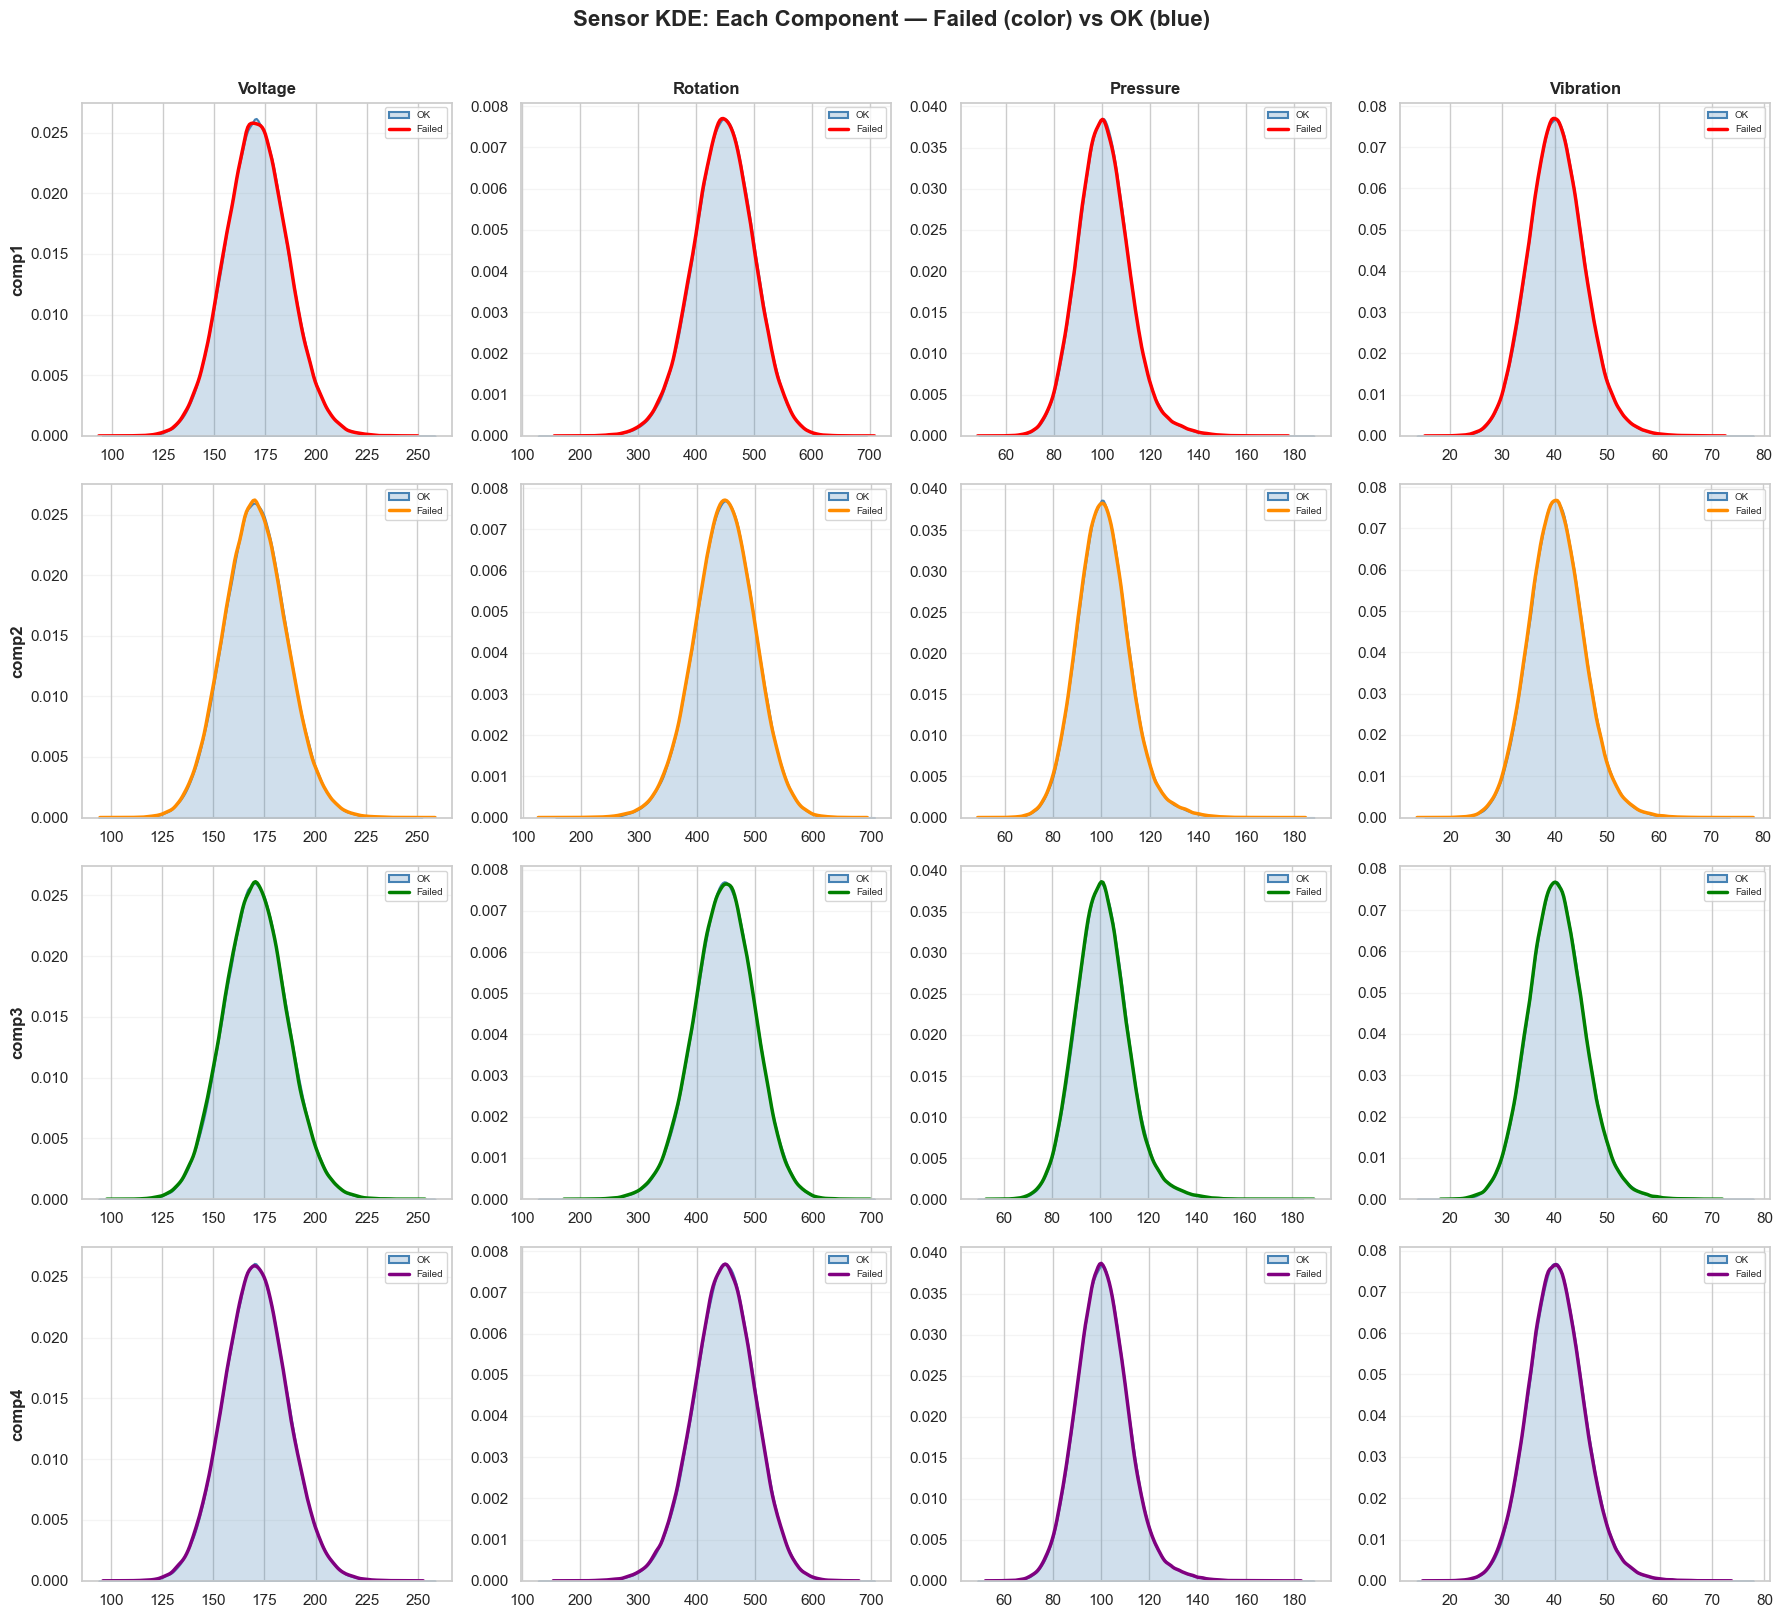

In [66]:
tele_cols   = ["telemetry_volt", "telemetry_rotate",
               "telemetry_pressure", "telemetry_vibration"]
tele_labels = ["Voltage", "Rotation", "Pressure", "Vibration"]
comp_names  = ["comp1", "comp2", "comp3", "comp4"]
fail_colors = ["red", "darkorange", "green", "purple"]

# 4 rows (components) × 4 columns (sensors)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))

for row, (comp, fcolor) in enumerate(zip(comp_names, fail_colors)):
    target = f"failures_features_failure_{comp}"

    for col_idx, (tele_col, tele_label) in enumerate(zip(tele_cols, tele_labels)):
        ax = axes[row, col_idx]

        fail_data   = df.loc[df[target] == True, tele_col].dropna()
        normal_data = df.loc[df[target] == False, tele_col].dropna()

        # Blue filled = OK
        sns.kdeplot(data=normal_data, ax=ax, color="steelblue",
                    linewidth=1.5, fill=True, alpha=0.25,
                    label=f"OK")

        # Colored line = Failed
        sns.kdeplot(data=fail_data, ax=ax, color=fcolor,
                    linewidth=2.5, label=f"Failed")

        # Labels
        if row == 0:
            ax.set_title(tele_label, fontsize=12, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(comp, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(axis="y", alpha=0.2)

plt.suptitle("Sensor KDE: Each Component — Failed (color) vs OK (blue)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Correlation Heatmap

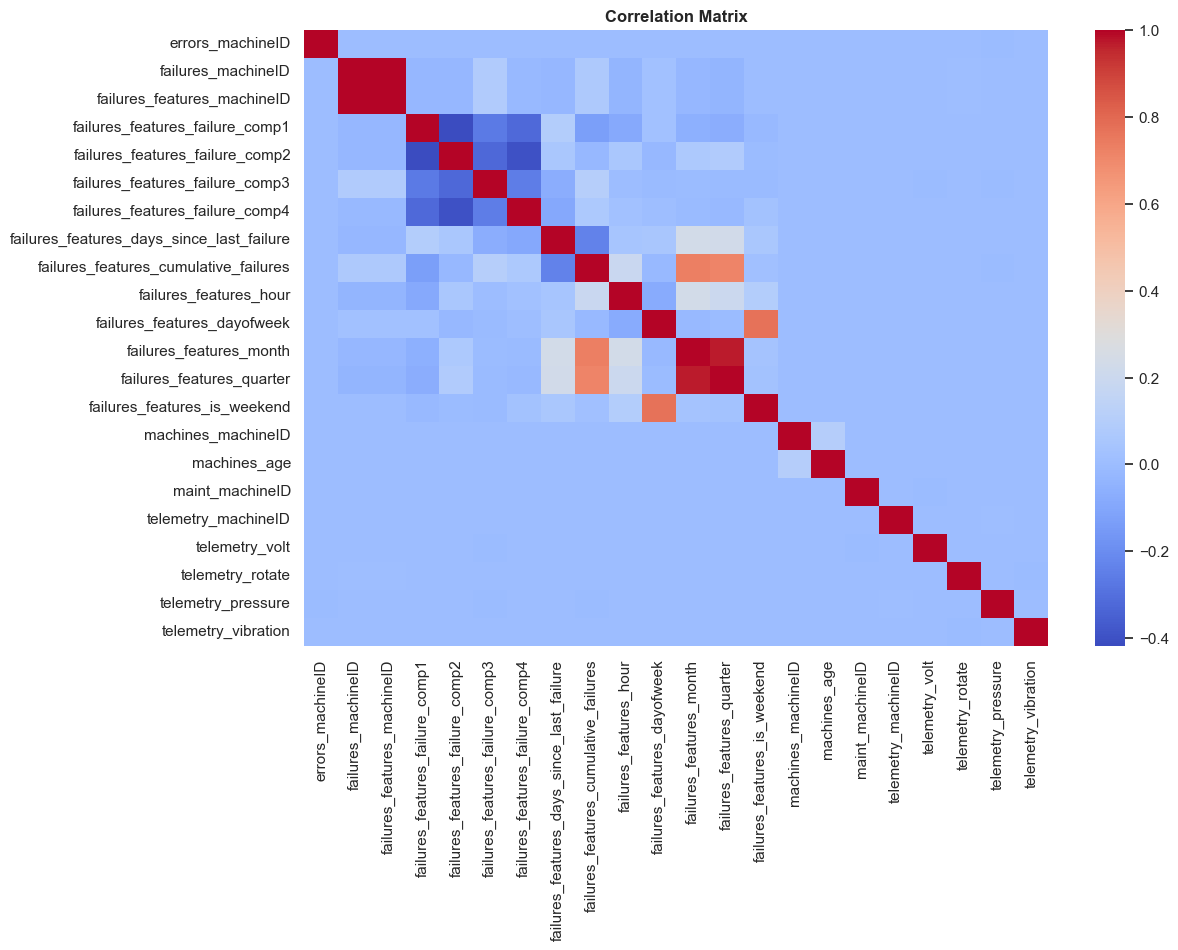

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Outliers Detection

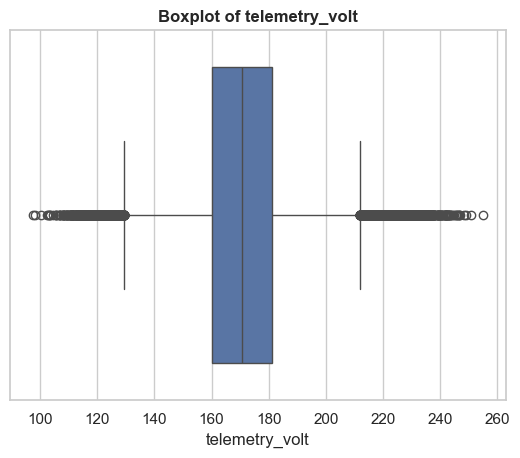

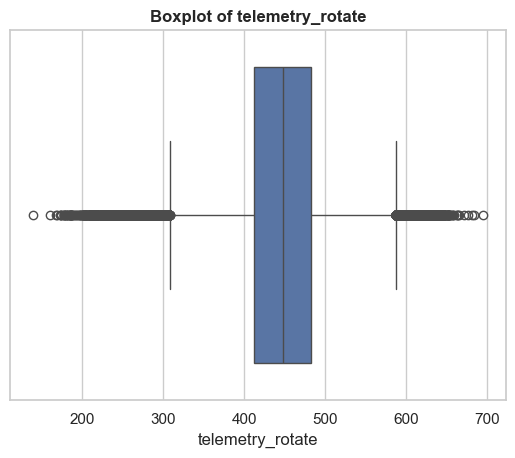

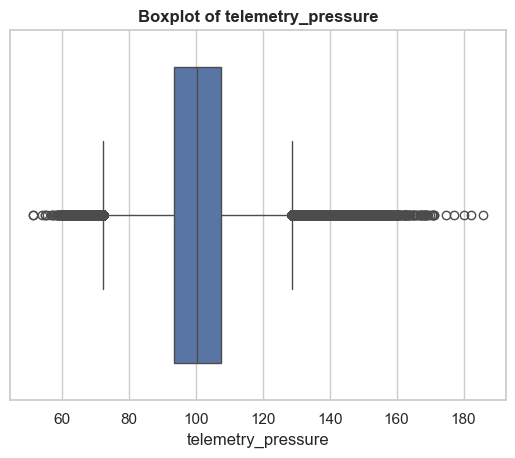

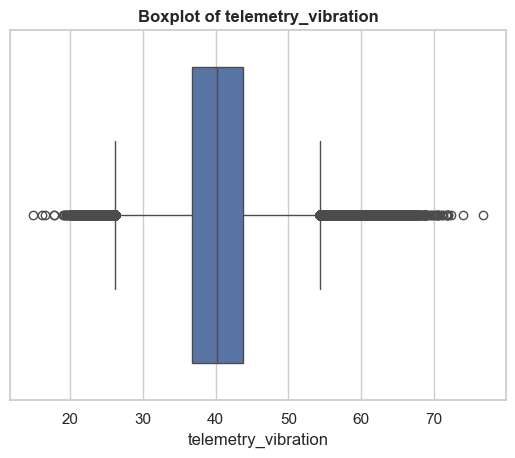

In [65]:
cols = ["telemetry_volt", "telemetry_rotate", "telemetry_pressure", "telemetry_vibration"]
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()